<a href="https://colab.research.google.com/github/meenakshi-kay/Orbit-Simulation/blob/main/Orbit_simulation_euler_vs_leapfrog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
#using sun and earth for now for simplicity

G= 6.67408e-11

M_star = 1.9891e30
M_planet = 5.9722e24

e = 0.0167
a = 1.496e11

# will test wiht other planets and stars later so variabele section

In [ ]:
# estimating orbital period first so timestep can scale with orbit size

T_estimate = (4*(math.pi**2)*(a**3)/(G*M_star))**(0.5)
print("Estimated time period (in days):", T_estimate/(60*60*24))

Estimated time period (in days): 365.2073450064896


In [ ]:
# can use any step but easier to do it this way. also any ratio high enough works

# starting with 10000 timesteps per orbit
# small enough to make orbit look smooth without taking forever to run

dt = T_estimate / 10000

# running multiple orbits to see how numerical error builds over time (check convergence)
# will try increasing orbits to see if that affects method accuracy
n_orbits = 5

n_steps = int((T_estimate/dt) * n_orbits) # total number of integration steps

# starting at periapsys(is??) because initial velocity and poaition are easiest to define there
r_peri = a * (1 - e)
initial_pos = np.array([r_peri, 0.0])

#usig vis-a-vis equation to calculate intial velocity (currently at periapsis)
init_vel_magnitude = np.sqrt(G * M_star * ((2/r_peri) - (1/a))) #just magnitude first

# velocity starts perpendicular to radius vector
# gives tangential motion needed for orbit
initial_vel = np.array([0.0, init_vel_magnitude])

In [ ]:
# keeping acceleration as separate function so it can be reused later for euler, leapfrog, RK4, etc
def calc_acceleration(pos):
    r = np.linalg.norm(pos)     #current distance from star
    return -G * M_star * pos / r**3       # acceleration points toward centre of attraction


# calculating total mechanical energy at every timestep mainly to check how much numerical error builds up
def total_energy(pos, vel):
    r = np.linalg.norm(pos)   #current distance from star
    speed = np.linalg.norm(vel)   #current velcotiy magnitude (aka speed yay)
    KE = 0.5 * M_planet * speed**2    #kinetic energy = 1/2 mv^2
    PE = -G * M_star * M_planet / r   #gravitational potential energy = -GMm/r
    return KE + PE    #total energy = ke + pe
    #should ideally remain const (energy conservation)

In [ ]:
# keeping Euler method in its own function easier to compare later

def euler(pos, vel, dt, n_steps):
    positions = []
    energies = []
    times = []

    #making copies so original initial conditions stay unchanged
    #bc python treats lists passed as arguments as pass by reference
    pos = pos.copy()
    vel = vel.copy()

    for i in range(n_steps):
        acc = calc_acceleration(pos)

        pos = pos + vel * dt    #updating position first using current velocity
        vel = vel + acc * dt    #updatig velocity using new acceleration

        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return ( np.array(positions), np.array(energies), np.array(times) )   #converiitng lists to arrays

In [ ]:
# storing orbit positions, energies, and times separately for plotting later
euler_positions, euler_energies, euler_times = euler( initial_pos, initial_vel, dt, n_steps )

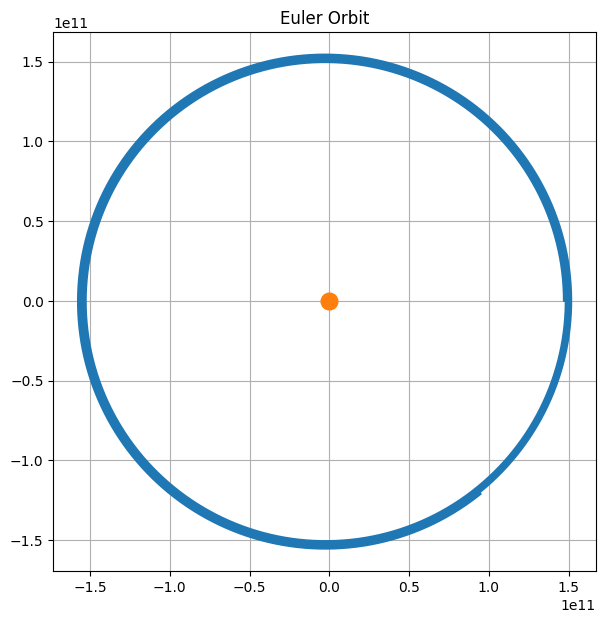

In [ ]:
plt.figure(figsize=(7,7))

plt.plot( euler_positions[:,0], euler_positions[:,1] )
plt.plot(0,0, marker='o', markersize=12)

plt.axis('equal')   #setting scales to be equal so the figure doesnt get distorted
plt.title("Euler Orbit")
plt.grid()

plt.show()

______________________________

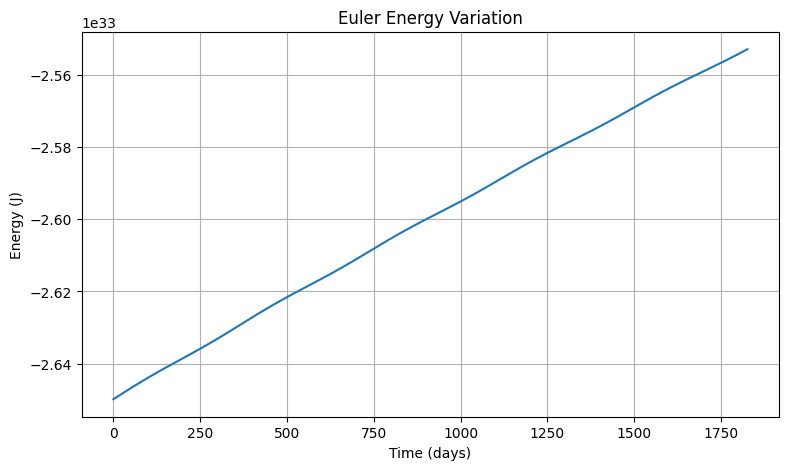

In [ ]:
# plotting total energy over time
# ideally this should stay constant if energy is conserved
# any drift here is numerical error from the integration method

plt.figure(figsize=(9,5))

# converting seconds to days so axis labels are easier to read
plt.plot( euler_times/(60*60*24), euler_energies )

plt.xlabel("Time (days)")
plt.ylabel("Energy (J)")

plt.title("Euler Energy Variation")
plt.grid()

plt.show()

In [ ]:
def run_leapfrog(pos, vel, dt, n_steps):
  # leapfrog splits the velocity update into two halves. one before moving the position and one after
    positions = []
    energies = []
    times = []

    # making copies so original initial conditions dont get mutated
    #(python uses call by reference wheh lists are passed as arguments so any changes wiuld affect eveyr instance of the list)
    pos = pos.copy()
    vel = vel.copy()

    #starting acceleration at initial postion
    #leapforgg always needs acceleration from the current position
    acc = calc_acceleration(pos)

    for i in range(n_steps):

        #first updating velocity by half a timestep. leapfrog staggers posutiton and velocity updates
        #so velocity is "half a step ahead" of pos
        vel_half = vel + 0.5 * acc * dt

        # updating position using the half-step velocity. moves planet to its nect postiosn
        pos = pos + vel_half * dt

        # position changes so gravity also changes so calc new acceleeration
        new_acc = calc_acceleration(pos)

        # second half of the velocity update.n ow velocity has advanced by one full timestep
        vel = vel_half + 0.5 * new_acc * dt

        #storing new acceleration
        acc = new_acc

        # stroing position,energy, time values to plot later
        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return (np.array(positions), np.array(energies), np.array(times))

In [ ]:
# running leapfrog simulation
leapfrog_positions, leapfrog_energies, leapfrog_times = run_leapfrog(initial_pos,initial_vel,dt,n_steps)

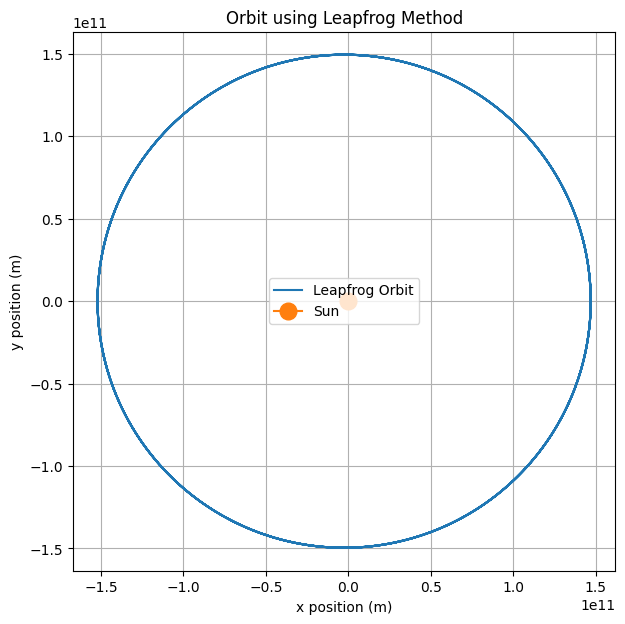

In [ ]:
# plotting orbital trajectory, sun is fixed at origin bc assuming  two-body system

plt.figure(figsize=(7,7))

plt.plot(leapfrog_positions[:,0], leapfrog_positions[:,1], label="Leapfrog Orbit" )

plt.plot(0,0, marker='o', markersize=12, label="Sun")

# keeping both axes on same scale so orbit shape isnt distorted
plt.axis('equal')
plt.title("Orbit using Leapfrog Method")

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend()
plt.grid()

plt.show()

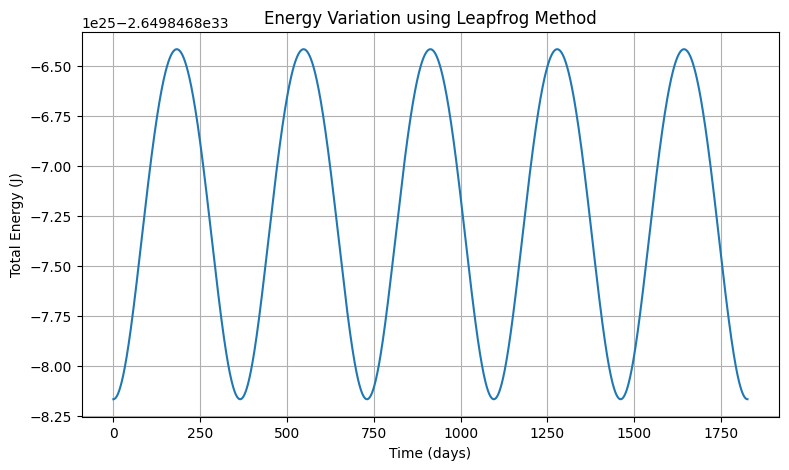

In [ ]:
# plotting total energy against time
# ideally this should remain nearly constant throughout
# comparing this later with euler

plt.figure(figsize=(9,5))

plt.plot(leapfrog_times/(60*60*24), leapfrog_energies)

plt.xlabel("Time (days)")
plt.ylabel("Total Energy (J)")

plt.title("Energy Variation using Leapfrog Method")
plt.grid()

plt.show()

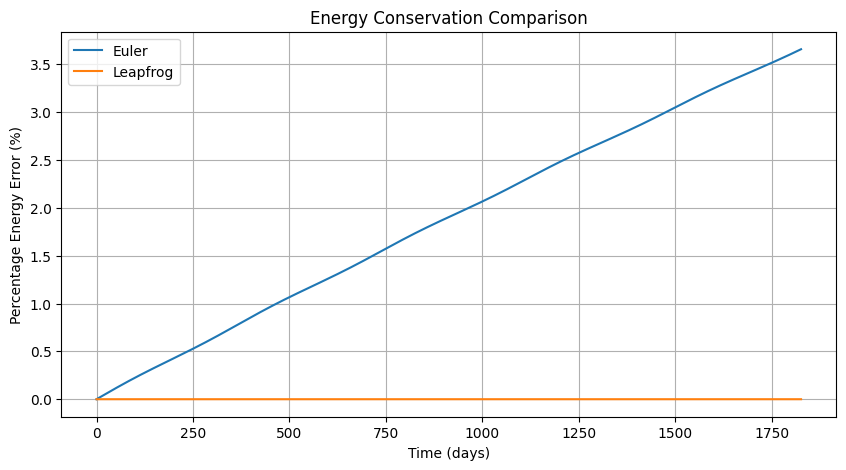

In [ ]:
# converting energy drift into percentage error
#easier to compare this way bc absolute energy values are huge

#using the initial energy as the reference value

euler_error = ((euler_energies - euler_energies[0]) / abs(euler_energies[0])) * 100
leapfrog_error = ((leapfrog_energies - leapfrog_energies[0]) / abs(leapfrog_energies[0])) * 100

plt.figure(figsize=(10,5))

# plotting percentage energy error against time
# lower error means better energy conservation which means better long-term stability
#(ideally should stay as close to zero as ppossoible)

plt.plot(euler_times/(60*60*24), euler_error, label="Euler")

plt.plot(leapfrog_times/(60*60*24), leapfrog_error, label="Leapfrog")

plt.xlabel("Time (days)")
plt.ylabel("Percentage Energy Error (%)")
plt.title("Energy Conservation Comparison")
plt.legend()
plt.grid()

plt.show()

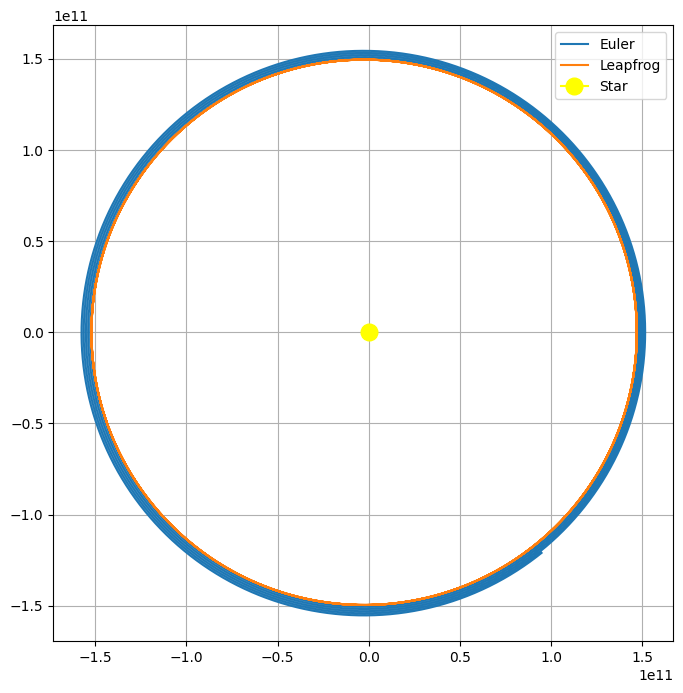

In [ ]:
# plotting both orbital trajectories on the same graph
#easier to see how numerical error affects the orbit shape over time

plt.figure(figsize=(8,8))

plt.plot(euler_positions[:,0], euler_positions[:,1], label="Euler")
plt.plot(leapfrog_positions[:,0], leapfrog_positions[:,1], label="Leapfrog")

plt.plot(0,0,marker='o',markersize=12,label="Star",color='yellow')    #central star fixed at origin (yellow bc fun)

plt.axis("equal")
plt.legend()
plt.grid()

plt.show()